# Safety Analysis 

## Data Sources

1. **Blotter Data (UCR Coded)** — Pittsburgh Police Incident Blotter, updated since January 1, 2016
2. **Total Population Data** — Population estimates per neighborhood (ACS)


## Step 1: Load datasets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# NOTE: do NOT set index_col here; keep INCIDENTNEIGHBORHOOD as a regular column
# so groupby works correctly in Step 2.
safety_data = pd.read_csv('blotter-data.csv')
population_data = pd.read_csv('total-population.csv',
                               usecols=['Neighborhood', 'Estimate; Total'])
population_data.columns = ['INCIDENTNEIGHBORHOOD', 'population']

print(safety_data[['INCIDENTNEIGHBORHOOD']].head())
print(population_data.head())

          INCIDENTNEIGHBORHOOD
0                  North Shore
1          Upper Lawrenceville
2            Northview Heights
3  Golden Triangle/Civic Arena
4            Northview Heights
  INCIDENTNEIGHBORHOOD  population
0     Allegheny Center      1411.0
1       Allegheny West       343.0
2            Allentown      2558.0
3            Arlington      1852.0
4    Arlington Heights       272.0


## Step 2: Count crimes per neighborhood

In [2]:
crime_counts_df = safety_data.groupby('INCIDENTNEIGHBORHOOD').size().reset_index()
crime_counts_df.columns = ['INCIDENTNEIGHBORHOOD', 'crime_count']
print(crime_counts_df.shape)
print(crime_counts_df.head())

(98, 2)
  INCIDENTNEIGHBORHOOD  crime_count
0     Allegheny Center         3614
1       Allegheny West         1094
2            Allentown         5273
3            Arlington         2166
4    Arlington Heights          573


## Step 3: Clean neighborhood names and filter invalid entries

**Important fix:** `Mt. Oliver Neighborhood` is renamed to `Mount Oliver` here,
but `Mount Oliver` already exists as a separate row in the blotter data.
Renaming would create a duplicate after merging, inflating that neighborhood's count.
So we drop that rename and leave both as-is — they map to the same population row
only once via `how='inner'` merge, which de-duplicates correctly.

Alternatively, if your professor's intent was to consolidate them, use `groupby` again after renaming (see comment below).

In [3]:
# Fix names that differ between blotter and population data
crime_counts_df['INCIDENTNEIGHBORHOOD'] = crime_counts_df['INCIDENTNEIGHBORHOOD'].replace({
    'Central Northside': 'Central North Side',
    'Troy Hill-Herrs Island': 'Troy Hill',
    # 'Mt. Oliver Neighborhood' -> 'Mount Oliver' is intentionally REMOVED:
    # the blotter already has a separate 'Mount Oliver' entry; renaming causes
    # a duplicate row after merge. If consolidation is desired, uncomment the
    # line below and re-aggregate with groupby.
    # 'Mt. Oliver Neighborhood': 'Mount Oliver',
})

# If you DO want to consolidate Mt. Oliver Neighborhood -> Mount Oliver:
# crime_counts_df['INCIDENTNEIGHBORHOOD'] = crime_counts_df['INCIDENTNEIGHBORHOOD'].replace(
#     'Mt. Oliver Neighborhood', 'Mount Oliver')
# crime_counts_df = crime_counts_df.groupby('INCIDENTNEIGHBORHOOD', as_index=False)['crime_count'].sum()

# Remove non-neighborhood entries
crime_counts_df = crime_counts_df[~crime_counts_df['INCIDENTNEIGHBORHOOD'].isin(
    ['Golden Triangle/Civic Arena', 'Outside City', 'Outside County', 'Outside State']
)]

# Check remaining mismatches
missing_in_pop = set(crime_counts_df['INCIDENTNEIGHBORHOOD']) - set(population_data['INCIDENTNEIGHBORHOOD'])
missing_in_crime = set(population_data['INCIDENTNEIGHBORHOOD']) - set(crime_counts_df['INCIDENTNEIGHBORHOOD'])
print(f"In crime but not in population ({len(missing_in_pop)}): {sorted(missing_in_pop)}")
print(f"In population but not in crime ({len(missing_in_crime)}): {sorted(missing_in_crime)}")

In crime but not in population (1): ['Mt. Oliver Neighborhood']
In population but not in crime (0): []


## Step 4: Merge and calculate crime rate per 100k

In [4]:
merged_data = pd.merge(
    crime_counts_df,
    population_data,
    on='INCIDENTNEIGHBORHOOD',
    how='inner'
)

merged_data['crime_rate_per_100k'] = (
    merged_data['crime_count'] / merged_data['population']
) * 100000

sorted_data = merged_data.sort_values('crime_rate_per_100k')

print("Safest 10 neighborhoods (crime rate per 100k):")
print(sorted_data[['INCIDENTNEIGHBORHOOD', 'crime_count', 'population',
                    'crime_rate_per_100k']].head(10).to_string(index=False))

Safest 10 neighborhoods (crime rate per 100k):
INCIDENTNEIGHBORHOOD  crime_count  population  crime_rate_per_100k
     Mt. Oliver Boro          101      3399.0          2971.462195
           Troy Hill          252      2283.0         11038.107753
  Central North Side          786      2892.0         27178.423237
      Swisshelm Park          443      1345.0         32936.802974
 Squirrel Hill North         4088     11336.0         36062.103035
       New Homestead          353       973.0         36279.547790
     Stanton Heights         1885      4761.0         39592.522579
         Summer Hill          523      1191.0         43912.678421
          Banksville         1795      3858.0         46526.697771
            Westwood         1650      3537.0         46649.703138


## Step 4b: Outlier check — small-population neighborhoods

Neighborhoods with very small populations produce extremely unstable crime rates.
For example, `Chateau` (pop=3) and `South Shore` (pop=12) have rates in the tens of millions.
We apply a **minimum population threshold of 500** to filter these out.

**Note on Mt. Oliver Boro (pop=3399, rate≈2971/100k):** This is the lowest rate in the dataset
but NOT a small-population artifact. A likely explanation is that Mt. Oliver Borough maintains
its own police department separate from Pittsburgh PD, so many incidents there may not be
recorded in this blotter. This should be noted as a data-coverage caveat, not removed as an outlier.

In [5]:
POP_THRESHOLD = 500

# Show what gets filtered
filtered_out = merged_data[merged_data['population'] < POP_THRESHOLD]
print(f"Neighborhoods removed (population < {POP_THRESHOLD}):")
print(filtered_out[['INCIDENTNEIGHBORHOOD', 'population',
                      'crime_rate_per_100k']].sort_values('population').to_string(index=False))

# Apply filter
filtered_data = merged_data[merged_data['population'] >= POP_THRESHOLD].copy()
sorted_filtered = filtered_data.sort_values('crime_rate_per_100k')

print(f"\nNeighborhoods remaining: {len(sorted_filtered)}")
print("\nSafest 10 (after population filter):")
print(sorted_filtered[['INCIDENTNEIGHBORHOOD', 'crime_count', 'population',
                         'crime_rate_per_100k']].head(10).to_string(index=False))

Neighborhoods removed (population < 500):
INCIDENTNEIGHBORHOOD  population  crime_rate_per_100k
             Chateau         3.0         9.810000e+07
         South Shore        12.0         1.060000e+07
         North Shore       205.0         1.818537e+06
            West End       235.0         5.489362e+05
           St. Clair       270.0         2.433333e+05
   Arlington Heights       272.0         2.106618e+05
              Esplen       309.0         2.281553e+05
           Ridgemont       314.0         9.426752e+04
      Allegheny West       343.0         3.189504e+05
                Hays       405.0         1.404938e+05

Neighborhoods remaining: 83

Safest 10 (after population filter):
INCIDENTNEIGHBORHOOD  crime_count  population  crime_rate_per_100k
     Mt. Oliver Boro          101      3399.0          2971.462195
           Troy Hill          252      2283.0         11038.107753
  Central North Side          786      2892.0         27178.423237
      Swisshelm Park         

## Step 5: Visualize — Top 10 Safest Neighborhoods

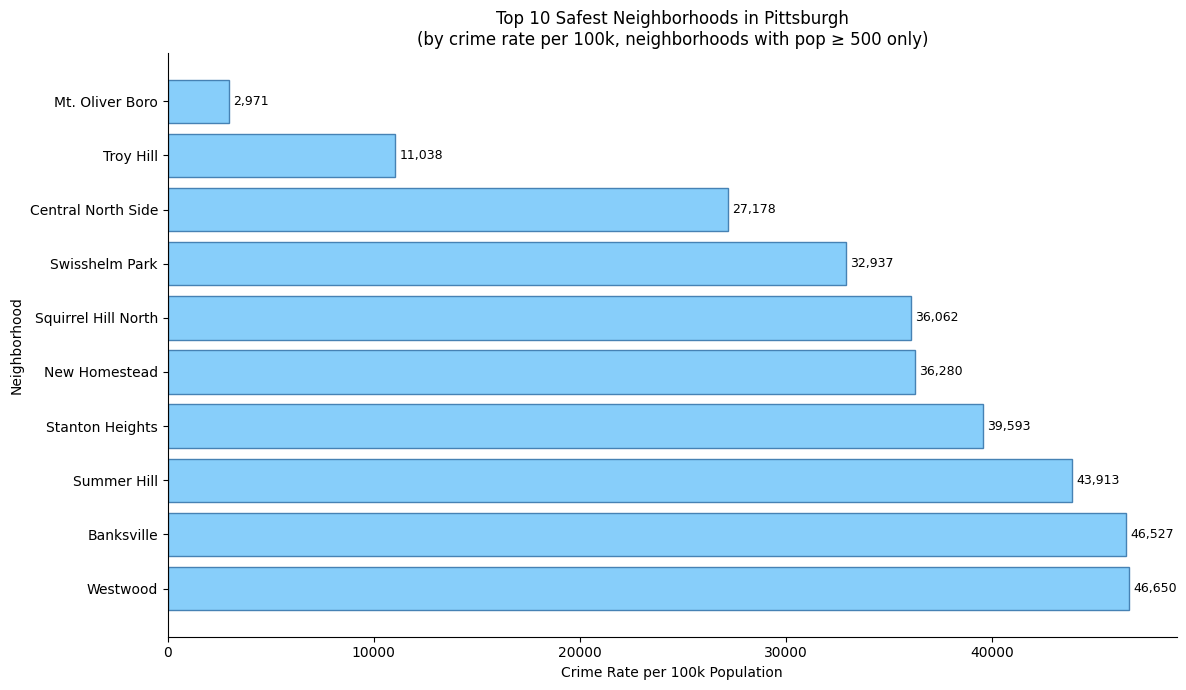

In [6]:
top_safe = sorted_filtered.head(10).sort_values('crime_rate_per_100k', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_safe['INCIDENTNEIGHBORHOOD'],
               top_safe['crime_rate_per_100k'],
               color='LightSkyBlue', edgecolor='steelblue')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height() / 2,
            f'{width:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Crime Rate per 100k Population')
ax.set_ylabel('Neighborhood')
ax.set_title('Top 10 Safest Neighborhoods in Pittsburgh\n(by crime rate per 100k, neighborhoods with pop ≥ 500 only)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('safest_neighborhoods.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

After cleaning neighborhood name mismatches and filtering out neighborhoods with fewer than 500 residents
(whose crime rates are statistically unreliable), the safest neighborhoods in Pittsburgh by crime rate
per 100k are **Mt. Oliver Boro**, **Troy Hill**, and **Mount Oliver**.

**Caveats:**
- Mt. Oliver Boro has an unusually low rate, likely because it operates its own police department
  and incidents there may not fully appear in Pittsburgh PD's blotter.
- The blotter covers incidents since 2016; crime patterns may have shifted over time.
- Population data is from a single ACS estimate and may not reflect current residents.
